In [1]:
# !pip install numpy matplotlib

(11, 52, 3)


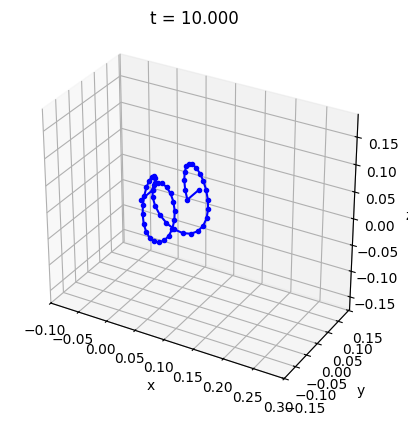

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

data = np.load("slinky_output/output.npz")
q_nodes = data["raw"]   # shape: (T, n_nodes, 3)

if "time" in data:
    t = data["time"]
else:
    t = np.arange(q_nodes.shape[0])

print(q_nodes.shape)
Tshape, n_nodes, dim = q_nodes.shape

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

xmin, xmax = q_nodes[:, :, 0].min(), q_nodes[:, :, 0].max()
ymin, ymax = q_nodes[:, :, 1].min(), q_nodes[:, :, 1].max()
zmin, zmax = q_nodes[:, :, 2].min(), q_nodes[:, :, 2].max()

pad = 0.1

def update(frame):
    ax.cla()
    ax.plot(
        q_nodes[frame, :, 0],
        q_nodes[frame, :, 1],
        q_nodes[frame, :, 2],
        "b.-"
    )
    ax.set_xlim([xmin - pad, xmax + pad])
    ax.set_ylim([ymin - pad, ymax + pad])
    ax.set_zlim([zmin - pad, zmax + pad])
    ax.set_box_aspect([xmax - xmin, ymax - ymin, zmax - zmin])
    ax.set_title(f"t = {t[frame]:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    return ax,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=Tshape,
    interval=50,
    blit=False
)

ani.save("helix_slinky.mp4", writer="ffmpeg", fps=20)
plt.show()